# Gender Inequality in Education and Employment - EDA

This notebook pulls data from the World Bank WDI and ILOSTAT, 
runs a coverage audit, and works through EDA for all three topic areas - 
education, labour force participation, and wages.

Run this notebook before modelling.ipynb. The data pull happens here and caches 
to data/raw/ so modelling.ipynb can load straight from disk.

In [7]:
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import gzip
import io
from pathlib import Path

# paths
ROOT = Path().resolve().parent
DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "outputs" / "figures"

# create dirs if they don't exist yet
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print("Setup complete")
print(f"Root: {ROOT}")

Setup complete
Root: C:\Users\gwach\Documents\Data-Science-Stuff\ds_workplace\Portfolio\gender-inequality


In [8]:
# countries
COUNTRIES = {
    "NGA": "Nigeria",
    "GHA": "Ghana",
    "KEN": "Kenya",
    "ZAF": "South Africa",
    "ETH": "Ethiopia",
    "BRA": "Brazil",
    "IND": "India",
    "DEU": "Germany",
    "BGD": "Bangladesh"
}

# World Bank indicators
WB_INDICATORS = {
    # education
    "SE.ENR.PRIM.FM.ZS":  "GPI primary enrollment",
    "SE.ENR.SECO.FM.ZS":  "GPI secondary enrollment",
    "SE.ENR.TERT.FM.ZS":  "GPI tertiary enrollment",
    "SE.PRM.CMPT.FE.ZS":  "Primary completion rate female",
    "SE.PRM.CMPT.MA.ZS":  "Primary completion rate male",
    "SE.ADT.LITR.FE.ZS":  "Adult literacy rate female",
    "SE.ADT.LITR.MA.ZS":  "Adult literacy rate male",
    # labour force participation
    "SL.TLF.CACT.FE.ZS":  "LFP rate female",
    "SL.TLF.CACT.MA.ZS":  "LFP rate male",
    "SL.TLF.CACT.FM.ZS":  "Ratio female to male LFP",
    "SL.UEM.TOTL.FE.ZS":  "Unemployment rate female",
    "SL.UEM.TOTL.MA.ZS":  "Unemployment rate male",
}

# period
START_YEAR = 1990
END_YEAR = 2024

print(f"Countries: {len(COUNTRIES)}")
print(f"WB indicators: {len(WB_INDICATORS)}")
print(f"Period: {START_YEAR} to {END_YEAR}")

Countries: 9
WB indicators: 12
Period: 1990 to 2024


In [9]:
WB_CACHE = DATA_RAW / "wb_raw.parquet"

if WB_CACHE.exists():
    wb_raw = pd.read_parquet(WB_CACHE)
    print(f"Loaded from cache: {WB_CACHE}")
else:
    print("Pulling from World Bank API...")
    raw = wb.data.DataFrame(
        series=list(WB_INDICATORS.keys()),
        economy=list(COUNTRIES.keys()),
        time=range(START_YEAR, END_YEAR + 1),
        skipBlanks=True,
        labels=False
    )

    # wbgapi returns a MultiIndex DataFrame - melt to long form
    raw.columns.name = "year"
    raw = raw.reset_index()
    wb_raw = raw.melt(
        id_vars=["economy", "series"],
        var_name="year",
        value_name="value"
    )
    wb_raw.columns = ["country", "indicator", "year", "value"]
    wb_raw["year"] = wb_raw["year"].str.extract(r"(\d{4})").astype(int)

    wb_raw.to_parquet(WB_CACHE, index=False)
    print(f"Saved to cache: {WB_CACHE}")

print(f"Shape: {wb_raw.shape}")
print(wb_raw.head())

Loaded from cache: C:\Users\gwach\Documents\Data-Science-Stuff\ds_workplace\Portfolio\gender-inequality\data\raw\wb_raw.parquet
Shape: (3640, 4)
  country          indicator  year    value
0     BGD  SE.ADT.LITR.FE.ZS  1990      NaN
1     BGD  SE.ADT.LITR.MA.ZS  1990      NaN
2     BGD  SE.ENR.PRIM.FM.ZS  1990  0.84442
3     BGD  SE.ENR.SECO.FM.ZS  1990  0.50819
4     BGD  SE.ENR.TERT.FM.ZS  1990  0.18946


## World Bank data pull

Pulled 12 indicators across 9 countries from 1990 to 2024. Long form schema: 
country, indicator, year, value - same canonical pattern as Project 6.

3640 rows against a theoretical max of 3780 - 140 rows dropped by skipBlanks 
meaning the API returned nothing for those country-indicator-year combinations. 
The coverage audit below will show exactly where the gaps sit.

In [10]:
# % of years with non-null values per country-indicator combination
total_years = END_YEAR - START_YEAR + 1

coverage = (
    wb_raw
    .groupby(["country", "indicator"])["value"]
    .apply(lambda x: x.notna().sum() / total_years * 100)
    .reset_index()
    .rename(columns={"value": "coverage_pct"})
)

# pivot to a readable heatmap shape
coverage_pivot = coverage.pivot(index="indicator", columns="country", values="coverage_pct")

# replace indicator codes with readable names
coverage_pivot.index = coverage_pivot.index.map(WB_INDICATORS)

print(coverage_pivot.round(1).to_string())

country                           BGD    BRA    DEU    ETH    GHA    IND    KEN    NGA    ZAF
indicator                                                                                    
Adult literacy rate female       40.0   60.0    NaN   22.9   14.3   34.3    2.9   17.1   34.3
Adult literacy rate male         40.0   60.0    NaN   22.9   14.3   34.3    2.9   20.0   34.3
GPI primary enrollment           34.3   54.3   82.9   91.4   77.1   82.9   65.7   80.0   80.0
GPI secondary enrollment         68.6   48.6   82.9   65.7   65.7   80.0   31.4   54.3   74.3
GPI tertiary enrollment          74.3   31.4   31.4   57.1   62.9   68.6   31.4   17.1   48.6
Primary completion rate female   22.9    NaN   68.6   65.7   62.9   48.6   14.3   22.9   42.9
Primary completion rate male     22.9    NaN   68.6   65.7   62.9   48.6   14.3   22.9   42.9
LFP rate female                 100.0  100.0  100.0  100.0  100.0  100.0  100.0  100.0  100.0
Ratio female to male LFP        100.0  100.0  100.0  100.0  

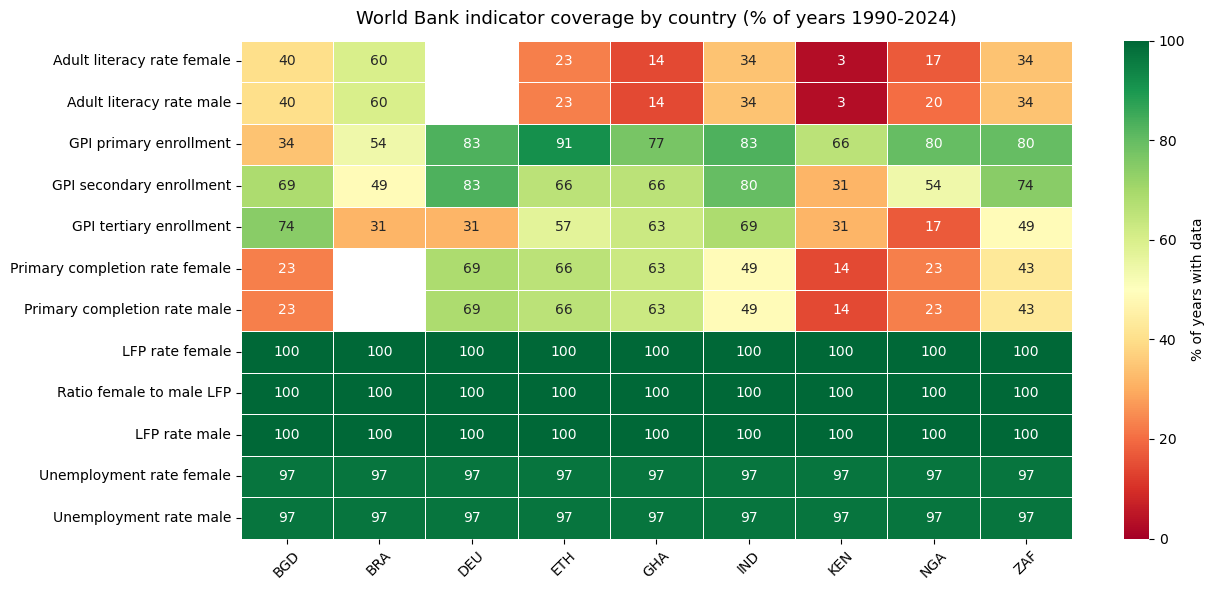

In [11]:
fig, ax = plt.subplots(figsize=(13, 6))

sns.heatmap(
    coverage_pivot,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "% of years with data"}
)

ax.set_title("World Bank indicator coverage by country (% of years 1990-2024)", fontsize=13, pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(FIGURES / "coverage_heatmap_wb.png", dpi=150, bbox_inches="tight")
plt.show()

## Coverage audit - World Bank indicators

Clear two-tier structure in the data.

LFP indicators are complete - 100% coverage across all countries and years for 
participation rates, 97% for unemployment. RQ2 has no data quality issues.

Education indicators are spottier. Adult literacy is effectively unusable for 
longitudinal analysis - Germany has no data, Kenya has 3% coverage (one point), 
Nigeria 17%. Primary completion rate has no Brazil data and thin coverage for 
Kenya and Nigeria.

The GPI enrollment indicators (primary, secondary, tertiary) are the strongest 
education series we have and will anchor RQ1. Literacy and completion rates will 
be used for descriptive context only, not in statistical tests or models.

This decision is driven by the data, not preference.

## Coverage audit - World Bank indicators

Clear two-tier structure in the data.

LFP indicators are complete - 100% coverage across all countries and years for 
participation rates, 97% for unemployment. RQ2 has no data quality issues.

Education indicators are spottier. Adult literacy is effectively unusable for 
longitudinal analysis - Germany has no data, Kenya has 3% coverage (one point), 
Nigeria 17%. Primary completion rate has no Brazil data and thin coverage for 
Kenya and Nigeria.

The GPI enrollment indicators (primary, secondary, tertiary) are the strongest 
education series we have and will anchor RQ1. Literacy and completion rates will 
be used for descriptive context only, not in statistical tests or models.

This decision is driven by the data, not preference.

In [14]:
ILO_CACHE = DATA_RAW / "ilo_raw.parquet"

ILO_INDICATORS = {
    "EAR_4MTH_SEX_ECO_CUR_NB_A": "Mean monthly earnings by sex and economic activity",
    "EAR_4MTH_SEX_OCU_CUR_NB_A": "Mean monthly earnings by sex and occupation",
}

OUR_COUNTRIES = list(COUNTRIES.keys())  # ISO3 codes

def fetch_ilo_indicator(code):
    url = (
        f"https://rplumber.ilo.org/data/indicator/"
        f"?id={code}&lang=en&format=.csv"
    )
    print(f"  Fetching {code} (all countries, will filter after)...")
    response = requests.get(url, timeout=180)
    response.raise_for_status()
    df = pd.read_csv(io.StringIO(response.text))
    # filter to our countries immediately - no point keeping 180+ countries
    df = df[df["ref_area"].isin(OUR_COUNTRIES)].copy()
    print(f"  Rows after country filter: {len(df)}")
    return df

if ILO_CACHE.exists():
    ilo_raw = pd.read_parquet(ILO_CACHE)
    print(f"Loaded from cache: {ILO_CACHE}")
else:
    print("Pulling from ILOSTAT API...")
    frames = []
    for code, label in ILO_INDICATORS.items():
        df = fetch_ilo_indicator(code)
        df["indicator_label"] = label
        frames.append(df)

    ilo_raw = pd.concat(frames, ignore_index=True)
    ilo_raw.to_parquet(ILO_CACHE, index=False)
    print(f"Saved to cache: {ILO_CACHE}")

print(f"\nFinal shape: {ilo_raw.shape}")
print(ilo_raw.head())

Pulling from ILOSTAT API...
  Fetching EAR_4MTH_SEX_ECO_CUR_NB_A (all countries, will filter after)...
  Rows after country filter: 27650
  Fetching EAR_4MTH_SEX_OCU_CUR_NB_A (all countries, will filter after)...


C:\Users\gwach\AppData\Local\Temp\ipykernel_33936\565943616.py:18: DtypeWarning: Columns (0: note_classif) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(io.StringIO(response.text))


  Rows after country filter: 13844
Saved to cache: C:\Users\gwach\Documents\Data-Science-Stuff\ds_workplace\Portfolio\gender-inequality\data\raw\ilo_raw.parquet

Final shape: (41494, 13)
  ref_area  source                indicator    sex          classif1  \
0      BGD  BA:673  EAR_EMTA_SEX_ECO_CUR_NB  SEX_T  ECO_SECTOR_TOTAL   
1      BGD  BA:673  EAR_EMTA_SEX_ECO_CUR_NB  SEX_T  ECO_SECTOR_TOTAL   
2      BGD  BA:673  EAR_EMTA_SEX_ECO_CUR_NB  SEX_T  ECO_SECTOR_TOTAL   
3      BGD  BA:673  EAR_EMTA_SEX_ECO_CUR_NB  SEX_T    ECO_SECTOR_AGR   
4      BGD  BA:673  EAR_EMTA_SEX_ECO_CUR_NB  SEX_T    ECO_SECTOR_AGR   

       classif2  time  obs_value obs_status note_classif note_indicator  \
0  CUR_TYPE_LCU  2024  15516.525        NaN          NaN        T30:114   
1  CUR_TYPE_PPP  2024    470.333        NaN          NaN        T30:114   
2  CUR_TYPE_USD  2024    134.222        NaN          NaN        T30:114   
3  CUR_TYPE_LCU  2024  10965.901        NaN          NaN        T30:114   
4  CU

In [15]:
print("=== unique indicators ===")
print(ilo_raw["indicator"].unique())

print("\n=== unique sex codes ===")
print(ilo_raw["sex"].unique())

print("\n=== unique currency types (classif2) ===")
print(ilo_raw["classif2"].unique())

print("\n=== unique sectors (classif1) - first indicator only ===")
eco = ilo_raw[ilo_raw["indicator"].str.contains("ECO")]
print(sorted(eco["classif1"].unique()))

print("\n=== year range ===")
print(f"min: {ilo_raw['time'].min()}  max: {ilo_raw['time'].max()}")

=== unique indicators ===
<ArrowStringArray>
['EAR_EMTA_SEX_ECO_CUR_NB', 'EAR_EMTA_SEX_OCU_CUR_NB']
Length: 2, dtype: str

=== unique sex codes ===
<ArrowStringArray>
['SEX_T', 'SEX_M', 'SEX_F', 'SEX_O']
Length: 4, dtype: str

=== unique currency types (classif2) ===
<ArrowStringArray>
['CUR_TYPE_LCU', 'CUR_TYPE_PPP', 'CUR_TYPE_USD']
Length: 3, dtype: str

=== unique sectors (classif1) - first indicator only ===
['ECO_AGGREGATE_AGR', 'ECO_AGGREGATE_CON', 'ECO_AGGREGATE_MAN', 'ECO_AGGREGATE_MEL', 'ECO_AGGREGATE_MKT', 'ECO_AGGREGATE_PUB', 'ECO_AGGREGATE_TOTAL', 'ECO_AGGREGATE_X', 'ECO_ISIC3_A', 'ECO_ISIC3_B', 'ECO_ISIC3_C', 'ECO_ISIC3_D', 'ECO_ISIC3_E', 'ECO_ISIC3_F', 'ECO_ISIC3_G', 'ECO_ISIC3_H', 'ECO_ISIC3_I', 'ECO_ISIC3_J', 'ECO_ISIC3_K', 'ECO_ISIC3_L', 'ECO_ISIC3_M', 'ECO_ISIC3_N', 'ECO_ISIC3_O', 'ECO_ISIC3_P', 'ECO_ISIC3_Q', 'ECO_ISIC3_TOTAL', 'ECO_ISIC3_X', 'ECO_ISIC4_A', 'ECO_ISIC4_B', 'ECO_ISIC4_C', 'ECO_ISIC4_D', 'ECO_ISIC4_E', 'ECO_ISIC4_F', 'ECO_ISIC4_G', 'ECO_ISIC4_H', 'ECO_I

In [16]:
# apply all four filters - currency, sex, sector classification, year range
ilo_clean = ilo_raw[
    (ilo_raw["classif2"] == "CUR_TYPE_PPP") &
    (ilo_raw["sex"].isin(["SEX_F", "SEX_M"])) &
    (ilo_raw["classif1"].str.startswith("ECO_SECTOR_")) &
    (ilo_raw["time"].between(START_YEAR, END_YEAR))
].copy()

print(f"Rows before filter: {len(ilo_raw)}")
print(f"Rows after filter:  {len(ilo_clean)}")
print(f"\nSectors remaining:")
print(sorted(ilo_clean["classif1"].unique()))
print(f"\nCountries remaining:")
print(sorted(ilo_clean["ref_area"].unique()))
print(f"\nYear range: {ilo_clean['time'].min()} to {ilo_clean['time'].max()}")

Rows before filter: 41494
Rows after filter:  1049

Sectors remaining:
['ECO_SECTOR_AGR', 'ECO_SECTOR_IND', 'ECO_SECTOR_NAG', 'ECO_SECTOR_SER', 'ECO_SECTOR_TOTAL', 'ECO_SECTOR_X']

Countries remaining:
['BGD', 'BRA', 'DEU', 'ETH', 'GHA', 'IND', 'KEN', 'NGA', 'ZAF']

Year range: 1990 to 2024


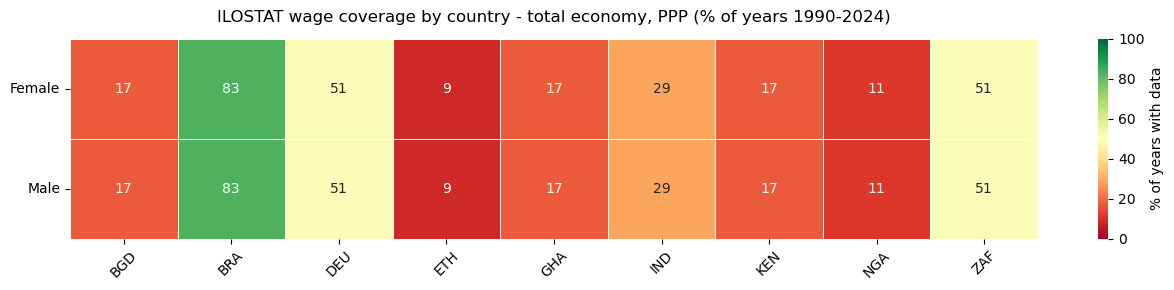

In [17]:
# coverage audit - % of years with non-null wage data per country and sex
ilo_coverage = (
    ilo_clean[ilo_clean["classif1"] == "ECO_SECTOR_TOTAL"]  # total economy only for now
    .groupby(["ref_area", "sex"])["obs_value"]
    .apply(lambda x: x.notna().sum() / (END_YEAR - START_YEAR + 1) * 100)
    .reset_index()
    .rename(columns={"obs_value": "coverage_pct"})
)

ilo_pivot = ilo_coverage.pivot(index="sex", columns="ref_area", values="coverage_pct")
ilo_pivot.index = ilo_pivot.index.map({"SEX_F": "Female", "SEX_M": "Male"})

fig, ax = plt.subplots(figsize=(13, 3))

sns.heatmap(
    ilo_pivot,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "% of years with data"}
)

ax.set_title("ILOSTAT wage coverage by country - total economy, PPP (% of years 1990-2024)", fontsize=12, pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(FIGURES / "coverage_heatmap_ilo.png", dpi=150, bbox_inches="tight")
plt.show()

## ILOSTAT wage coverage audit

Coverage is thin for most African countries in our sample. Brazil is the 
standout at 83%. Germany and South Africa sit at 51%. Nigeria, Ethiopia, 
Ghana, Kenya and Bangladesh are all below 20% - too sparse for longitudinal 
regression.

Female and male coverage are identical per country - when a country reports 
wages it reports both sexes. The gap is a country reporting problem, not a 
gender reporting problem.

This directly affects RQ3. We cannot do longitudinal wage regression on 
9-17% coverage. We need to decide how to adapt the question.